# Servette FC


In [ ]:
#Importing data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.model_selection import GridSearchCV, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import joblib
data = pd.read_csv('/content/Cleaned_df (27).csv')
data.tail()

,Competition,Matchday,Time,Home Team,Ranking Home Team,Away Team,Ranking Away Team,Attendance,Precipitation (mm),Temperature (°C),...,Max Capacity,Home Team Goals Scored,Away Team Goals Scored,Match Type,Home Team Outcome,Away Team Outcome,Goals Scored in Last 5 Games,Goals Conceded in Last 5 Games,Number of Wins in Last 5 Games,Derby
81,UEFA Conference League Qualifiers,Qualifying Round 2nd leg,20:30,Servette FC,0,Chelsea,0,28.000,0.0,23.8,...,30084,2,1,Normal Time,Win,Loss,6.0,9.0,2.0,0
82,Super League,8,18:00,Servette FC,5,Lausanne-Sport,8,12.185,0.2,10.5,...,30084,1,0,Normal Time,Win,Loss,7.0,6.0,2.0,0
83,Super League,10,20:30,Servette FC,4,FC Sion,7,12.987,0.0,13.3,...,30084,3,0,Normal Time,Win,Loss,6.0,5.0,2.0,1
84,Super League,12,20:30,Servette FC,1,FC Luzern,5,9.531,0.0,11.8,...,30084,2,2,Normal Time,Draw,Draw,8.0,6.0,2.0,0
85,Super League,14,20:30,Servette FC,3,FC Zürich,1,11.348,0.0,10.9,...,30084,1,1,Normal Time,Draw,Draw,8.0,6.0,2.0,0


<ipython-input-2-7096819d1dc5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Month'] = pd.Categorical(data['Month'],


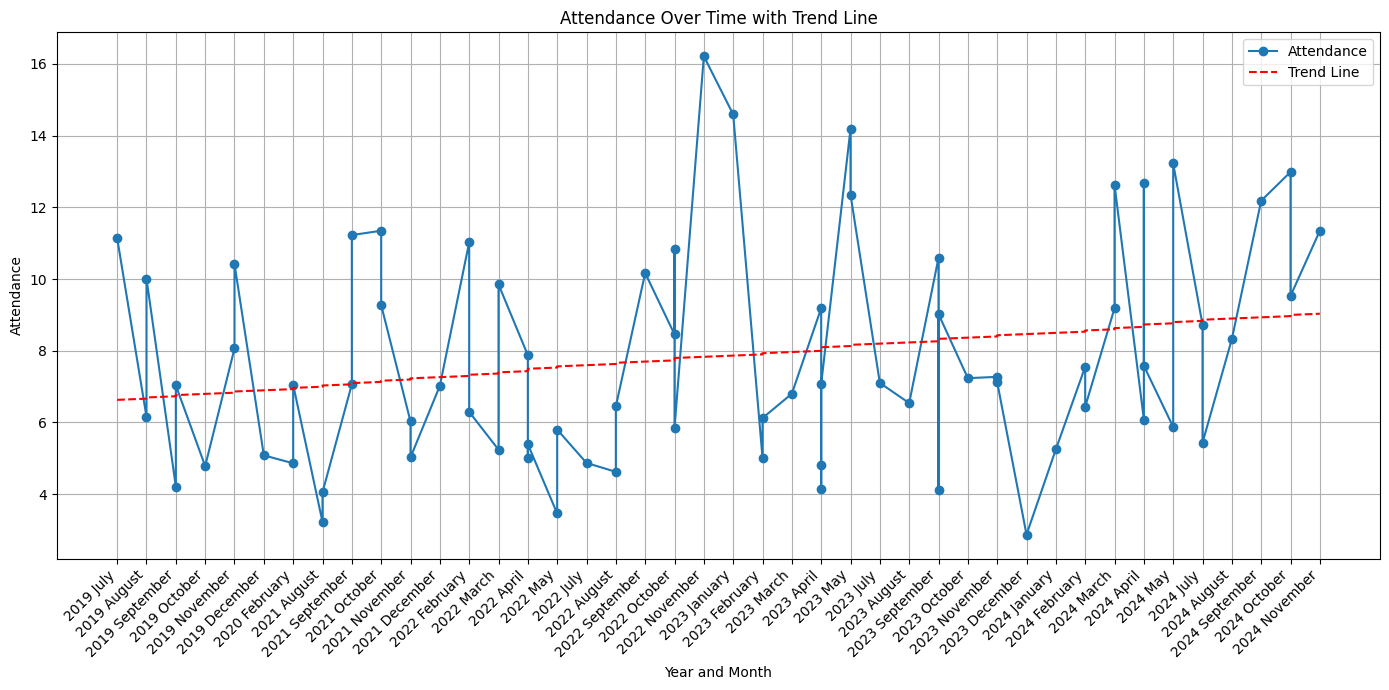

In [ ]:

data = data[data['Competition'] == 'Super League']
data['Month'] = pd.Categorical(data['Month'],
                                categories=["January", "February", "March", "April", "May", "June",
                                            "July", "August", "September", "October", "November", "December"],
                                ordered=True)
#sorting months
data_sorted = data.sort_values(by=["Year", "Month"])
data_sorted['Year_Month'] = data_sorted['Year'].astype(str) + " " + data_sorted['Month'].astype(str)
data_sorted['Time_Index'] = range(len(data_sorted))

#plotting attendance over time
trend_coefficients = np.polyfit(data_sorted['Time_Index'], data_sorted['Attendance'], 1)
trend_line = np.poly1d(trend_coefficients)

plt.figure(figsize=(14, 7))
plt.plot(data_sorted['Year_Month'], data_sorted['Attendance'], marker='o', linestyle='-', label="Attendance")
plt.plot(data_sorted['Year_Month'], trend_line(data_sorted['Time_Index']), color='red', linestyle='--', label="Trend Line")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title("Attendance Over Time with Trend Line")
plt.xlabel("Year and Month")
plt.ylabel("Attendance")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

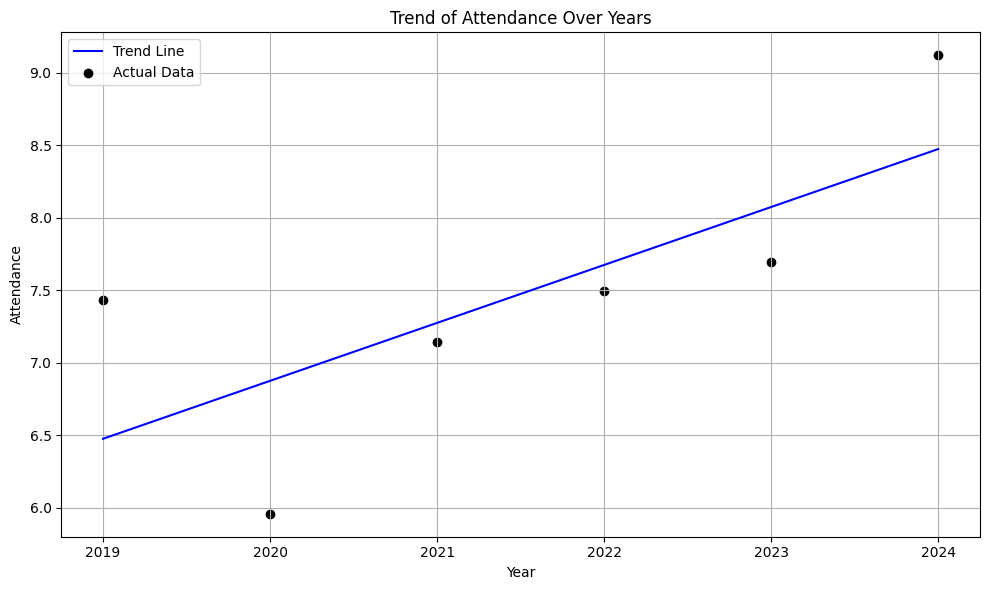

In [ ]:
#over only year and not month
data_yearly = data.groupby('Year')['Attendance'].mean().reset_index()
trend_coefficients = np.polyfit(data_yearly['Year'], data_yearly['Attendance'], 1)
trend_line = np.poly1d(trend_coefficients)
plt.figure(figsize=(10, 6))
plt.plot(data_yearly['Year'], trend_line(data_yearly['Year']), color='blue', linestyle='-', label="Trend Line")
plt.scatter(data_yearly['Year'], data_yearly['Attendance'], color='black', label="Actual Data")
plt.title("Trend of Attendance Over Years")
plt.xlabel("Year")
plt.ylabel("Attendance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#final cleaning
columns_to_remove = [
    'Home Team', 'Away Team',
    'Home Team Goals Scored', 'Away Team Goals Scored',
    'Home Team Outcome', 'Away Team Outcome', 'Match Type', 'Max Capacity', 'Month'
]

data_cleaned = data.drop(columns=columns_to_remove)
dataa = data_cleaned[data_cleaned['Competition'] == 'Super League']
dataaa = dataa.drop(columns=['Competition'])

weekday_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
dataaa['Weekday'] = dataaa['Weekday'].apply(
    lambda x: 'Weekday' if x in weekday_days else x
)
dataaaa = pd.get_dummies(dataaa, columns=['Weekday'], drop_first=False)
SFC = dataaaa.replace({True: 1, False: 0})
SFC = SFC.drop(columns=['Weekday_Sunday'])

def time_to_float(time_str):
    hours, minutes = map(int, time_str.split(":"))
    return hours + minutes / 60
SFC["Time"] = SFC["Time"].apply(time_to_float)

SFC.head(20)

<ipython-input-4-9aa76259040f>:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  SFC = dataaaa.replace({True: 1, False: 0})


,Matchday,Time,Ranking Home Team,Ranking Away Team,Attendance,Precipitation (mm),Temperature (°C),Year,Goals Scored in Last 5 Games,Goals Conceded in Last 5 Games,Number of Wins in Last 5 Games,Derby,Weekday_Saturday,Weekday_Weekday
0,2,19.00,6,9,11.142,2.6,20.3,2019,13.0,12.0,3.0,1,1,0
1,3,16.00,7,2,6.159,0.0,28.6,2019,13.0,10.0,3.0,0,0,0
2,6,19.00,4,9,10.012,0.0,28.4,2019,11.0,9.0,3.0,0,1,0
3,8,20.00,5,8,4.212,0.0,16.2,2019,8.0,8.0,3.0,0,0,1
4,9,16.00,5,7,7.036,0.0,24.5,2019,7.0,3.0,3.0,0,0,0
5,11,16.00,6,3,4.784,0.0,17.0,2019,6.0,4.0,2.0,0,0,0
6,13,16.00,7,1,8.065,1.1,11.3,2019,4.0,6.0,0.0,0,0,0
7,15,19.00,5,2,10.420,0.0,8.1,2019,8.0,7.0,1.0,0,1,0
8,18,19.00,5,10,5.084,1.0,7.5,2019,7.0,7.0,3.0,0,1,0
9,20,16.00,4,10,4.862,0.3,11.8,2020,6.0,8.0,3.0,0,0,0


Average Prediction: 7.83
MSE using average prediction: 9.10
   Actual  Predicted_Moving_Avg  Predicted_Average
0  11.142              7.832151           7.832151
1   6.159              7.832151           7.832151
2  10.012              7.832151           7.832151
3   4.212              7.832151           7.832151
4   7.036              7.832151           7.832151
5   4.784              7.712200           7.832151
6   8.065              6.440600           7.832151
7  10.420              6.821800           7.832151
8   5.084              6.903400           7.832151
9   4.862              7.077800           7.832151


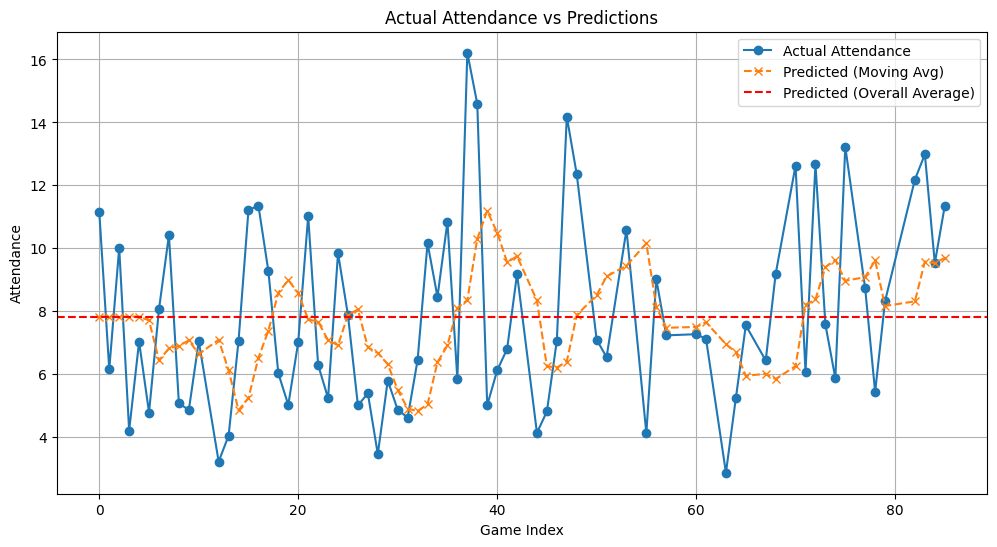

In [ ]:
attendance = SFC["Attendance"]

average_prediction = np.mean(attendance)
predictions = [average_prediction] * len(attendance)
mse_average = mean_squared_error(attendance, predictions)

print(f"Average Prediction: {average_prediction:.2f}")
print(f"MSE using average prediction: {mse_average:.2f}")

predicted_moving_avg = attendance.rolling(window=5).mean().shift(1)  # Rolling average with a shift for prediction
predicted_moving_avg = predicted_moving_avg.fillna(attendance.mean())  # Fill NaN for the first few games

# Calculate MSE for the moving average predictions
mse_moving_avg = mean_squared_error(attendance, predicted_moving_avg)


# 3. Display actual vs predictions for moving average
comparison_df = pd.DataFrame({
    "Actual": attendance,
    "Predicted_Moving_Avg": predicted_moving_avg,
    "Predicted_Average": predictions
})
print(comparison_df.head(10))
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(attendance.index, attendance, label="Actual Attendance", marker="o")
plt.plot(attendance.index, predicted_moving_avg, label="Predicted (Moving Avg)", linestyle="--", marker="x")
plt.axhline(average_prediction, color="red", linestyle="dashed", label="Predicted (Overall Average)")
plt.xlabel("Game Index")
plt.ylabel("Attendance")
plt.title("Actual Attendance vs Predictions")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
y = SFC["Attendance"]
X = SFC.drop(columns=["Attendance"])
average_y = y.mean()
print(f"The average of y (Attendance) is: {average_y}")

The average of y (Attendance) is: 7.832150684931507


In [ ]:
#LinearRegression
y = SFC["Attendance"]
X = SFC.drop(columns=["Attendance"])

mse_list = []

for random_state in range(101):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    linear_model = LinearRegression()
    linear_model.fit(X_train_scaled, y_train)

    y_pred = linear_model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)


mean_mse = np.mean(mse_list)

print(f"Mean MSE across 101 random states: {mean_mse:.2f}")

Mean MSE across 101 random states: 9.88


In [ ]:
#RandomForest
y = SFC["Attendance"]
X = SFC.drop(columns=["Attendance"])
# Iterating through random states for random forest
mse_list = []
for random_state in range(100):
    print(f"Processing random state {random_state}...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    rf_model = RandomForestRegressor(random_state=random_state, n_jobs=-1)
    rf_model.fit(X_train, y_train)

    y_test_pred = rf_model.predict(X_test)

    mse = mean_squared_error(y_test, y_test_pred)
    mse_list.append(mse)

mean_mse = np.mean(mse_list)

print(f"Mean MSE across 30 random states: {mean_mse}")

Processing random state 0...
Processing random state 1...
Processing random state 2...
Processing random state 3...
Processing random state 4...
Processing random state 5...
Processing random state 6...
Processing random state 7...
Processing random state 8...
Processing random state 9...
Processing random state 10...
Processing random state 11...
Processing random state 12...
Processing random state 13...
Processing random state 14...
Processing random state 15...
Processing random state 16...
Processing random state 17...
Processing random state 18...
Processing random state 19...
Processing random state 20...
Processing random state 21...
Processing random state 22...
Processing random state 23...
Processing random state 24...
Processing random state 25...
Processing random state 26...
Processing random state 27...
Processing random state 28...
Processing random state 29...
Processing random state 30...
Processing random state 31...
Processing random state 32...
Processing random st

In [ ]:
SFC.to_csv("SFC.csv", index=False)


In [ ]:
#Iterations Of Random States over multiple models with hyperparameter optimization
y = SFC["Attendance"]
X = SFC.drop(columns=["Attendance"])

results = []

for random_state in range(100):
    print(f"Processing random state {random_state}...")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    param_grid_ridge = {'alpha': np.linspace(74, 76, 10).tolist()}
    param_grid_lasso = {'alpha': np.linspace(0.45, 0.55, 10).tolist()}
    param_grid_elastic = {'alpha': np.linspace(0.51, 0.53, 10).tolist(), 'l1_ratio': np.linspace(0.99, 1.05, 10).tolist()}
    param_grid_sgd = {'alpha': np.linspace(0, 1, 30).tolist(), 'penalty': ['l2', 'l1', 'elasticnet']}

    # Perform Grid Search for Ridge Regression
    ridge = Ridge()
    grid_search_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_ridge.fit(X_train_scaled, y_train)
    best_alpha_ridge = grid_search_ridge.best_params_['alpha']

    # Perform Grid Search for Lasso Regression
    lasso = Lasso()
    grid_search_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_lasso.fit(X_train_scaled, y_train)
    best_alpha_lasso = grid_search_lasso.best_params_['alpha']

    # Perform Grid Search for ElasticNet Regression
    elastic_net = ElasticNet()
    grid_search_elastic = GridSearchCV(elastic_net, param_grid_elastic, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_elastic.fit(X_train_scaled, y_train)
    best_params_elastic = grid_search_elastic.best_params_

    # Perform Grid Search for SGD Regressor
    sgd = SGDRegressor(max_iter=1000, random_state=random_state)
    grid_search_sgd = GridSearchCV(sgd, param_grid_sgd, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_sgd.fit(X_train_scaled, y_train)
    best_params_sgd = grid_search_sgd.best_params_

    # Re-run cross-validation with the best parameters and evaluate
    def cross_validate_and_evaluate(model, X, y, model_name):
        y_pred = cross_val_predict(model, X, y, cv=5)
        mse = mean_squared_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        return mse, r2

    ridge_model = Ridge(alpha=best_alpha_ridge)
    ridge_mse, ridge_r2 = cross_validate_and_evaluate(ridge_model, X_train_scaled, y_train, "Ridge Regression")

    lasso_model = Lasso(alpha=best_alpha_lasso)
    lasso_mse, lasso_r2 = cross_validate_and_evaluate(lasso_model, X_train_scaled, y_train, "Lasso Regression")

    elastic_model = ElasticNet(alpha=best_params_elastic['alpha'], l1_ratio=best_params_elastic['l1_ratio'])
    elastic_mse, elastic_r2 = cross_validate_and_evaluate(elastic_model, X_train_scaled, y_train, "ElasticNet Regression")

    sgd_model = SGDRegressor(alpha=best_params_sgd['alpha'], penalty=best_params_sgd['penalty'], max_iter=1000, random_state=random_state)
    sgd_mse, sgd_r2 = cross_validate_and_evaluate(sgd_model, X_train_scaled, y_train, "Stochastic Gradient Descent (SGD)")

    # Append the results for this random state
    results.append({
        "random_state": random_state,
        "ridge_mse": ridge_mse,
        "lasso_mse": lasso_mse,
        "elastic_mse": elastic_mse,
        "sgd_mse": sgd_mse,
        "ridge_r2": ridge_r2,
        "lasso_r2": lasso_r2,
        "elastic_r2": elastic_r2,
        "sgd_r2": sgd_r2
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)


print("Average Results Across Random States:")
print(results_df[["ridge_mse", "lasso_mse", "elastic_mse", "sgd_mse"]].mean())
print(results_df[["ridge_r2", "lasso_r2", "elastic_r2", "sgd_r2"]].mean())



Processing random state 0...


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
400 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils

Processing random state 1...


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
400 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils

Processing random state 2...


...

Processing random state 98...


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
400 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils

Processing random state 99...


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
400 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils

Average Results Across Random States:
ridge_mse      8.419692
lasso_mse      8.149204
elastic_mse    8.239573
sgd_mse        8.104149
dtype: float64
ridge_r2      0.061424
lasso_r2      0.090801
elastic_r2    0.080817
sgd_r2        0.096263
dtype: float64


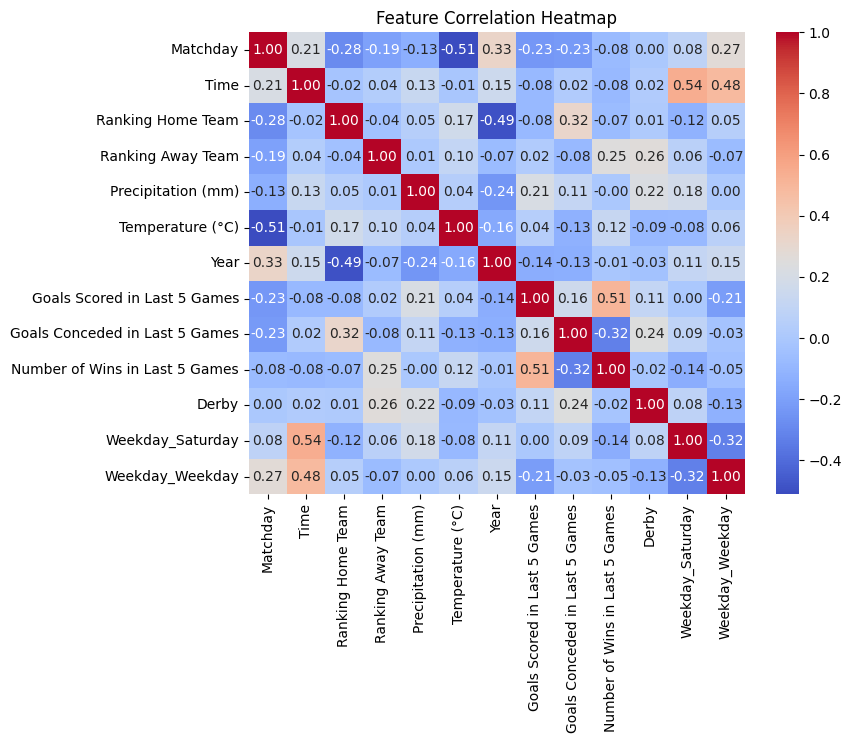

In [ ]:
correlation_matrix = X.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


Processing random state 0...
Processing random state 1...
Processing random state 2...
Processing random state 3...
Processing random state 4...
Processing random state 5...
Processing random state 6...
Processing random state 7...
Processing random state 8...
Processing random state 9...
Processing random state 10...
Processing random state 11...
Processing random state 12...
Processing random state 13...
Processing random state 14...
Processing random state 15...
Processing random state 16...
Processing random state 17...
Processing random state 18...
Processing random state 19...
Processing random state 20...
Processing random state 21...
Processing random state 22...
Processing random state 23...
Processing random state 24...
Processing random state 25...
Processing random state 26...
Processing random state 27...
Processing random state 28...
Processing random state 29...
Processing random state 30...
Processing random state 31...
Processing random state 32...
Processing random st

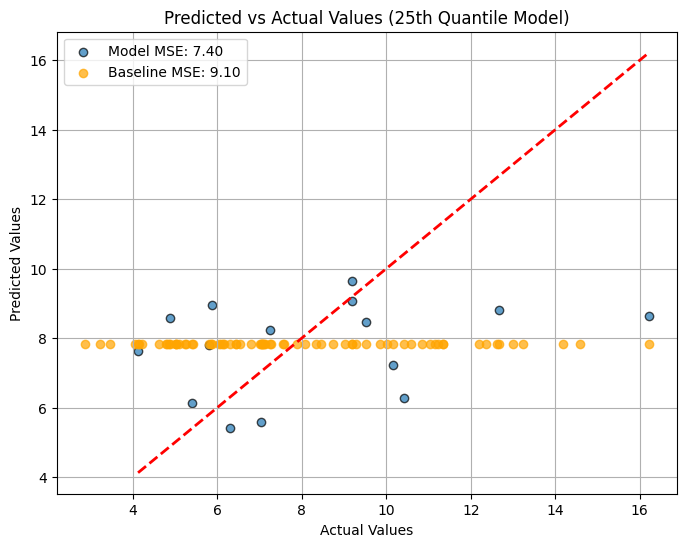

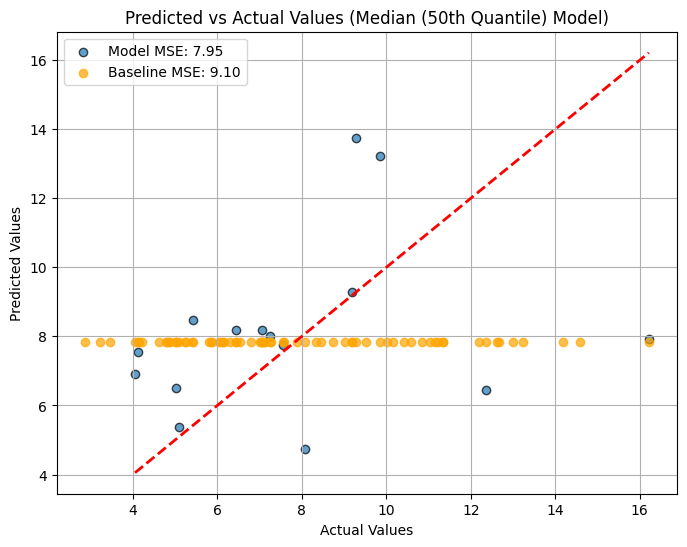

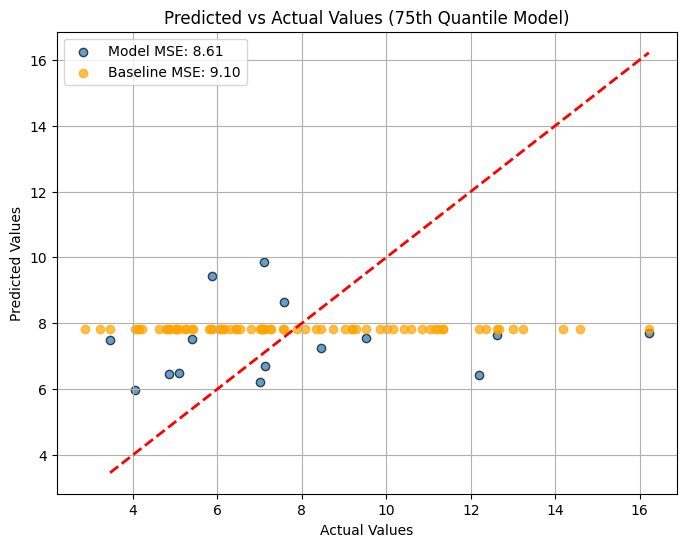

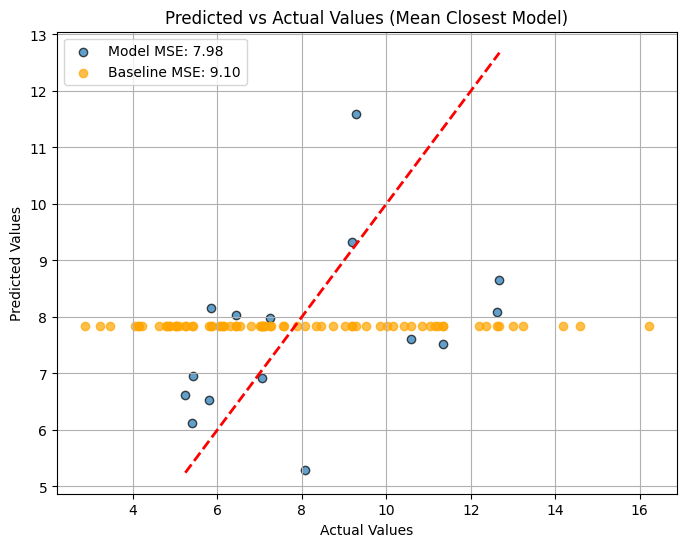

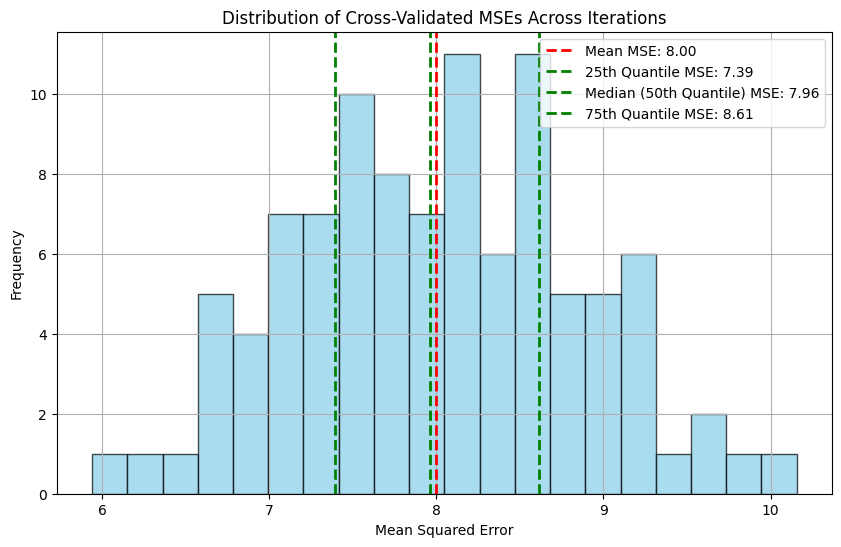

In [ ]:

# Assuming SFC is a DataFrame with the Attendance column
y = SFC["Attendance"]
X = SFC.drop(columns=["Attendance"])

# Initialize a list to store cross-validated MSEs and random states
cross_val_mse_list = []
random_state_list = []

# Define parameter grid for SGD
param_grid_sgd = {'alpha': np.linspace(0, 1, 30).tolist(), 'penalty': ['l2', 'l1', 'elasticnet']}

# Loop over 100 random states
for random_state in range(100):
    print(f"Processing random state {random_state}...")

    # Train-test split with the current random state
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Perform Grid Search for SGDRegressor with 5-fold cross-validation
    sgd = SGDRegressor(max_iter=1000, random_state=random_state)
    grid_search_sgd = GridSearchCV(sgd, param_grid_sgd, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_sgd.fit(X_train_scaled, y_train)

    # Get the best parameters
    best_params_sgd = grid_search_sgd.best_params_

    # Train SGD with the best alpha and penalty using cross-validation
    sgd_model = SGDRegressor(
        alpha=best_params_sgd['alpha'],
        penalty=best_params_sgd['penalty'],
        max_iter=1000,
        random_state=random_state
    )
    cross_val_scores = cross_val_score(
        sgd_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error'
    )
    cross_val_mse = -np.mean(cross_val_scores)  # Mean of cross-validation MSEs
    cross_val_mse_list.append(cross_val_mse)
    random_state_list.append(random_state)

# Calculate the mean cross-validated MSE across all iterations
mean_cross_val_mse = np.mean(cross_val_mse_list)

# Find the random states for the 25th, 50th, and 75th percentiles
quantiles = np.percentile(cross_val_mse_list, [25, 50, 75])

# Find the closest MSE to the mean
closest_mean_index = np.argmin(np.abs(np.array(cross_val_mse_list) - mean_cross_val_mse))

# Get the indices for each quantile
quantile_indices = [
    np.argmin(np.abs(np.array(cross_val_mse_list) - q)) for q in quantiles
]

# Add the mean closest index to the list
quantile_indices.append(closest_mean_index)
quantile_labels = ['25th Quantile', 'Median (50th Quantile)', '75th Quantile', 'Mean Closest']

# Calculate the overall average attendance as a baseline
average_attendance = np.mean(y)
y_avg_pred = np.full_like(y, average_attendance)

# Calculate the MSE of the average attendance across the entire dataset
mse_avg = mean_squared_error(y, y_avg_pred)
print(f"Baseline Average Attendance MSE: {mse_avg:.2f}")

# Plot predicted vs. actual values for each selected model
for i, idx in enumerate(quantile_indices):
    random_state = random_state_list[idx]
    mse = cross_val_mse_list[idx]

    # Train-test split with the selected random state
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SGDRegressor with the best parameters for this random state
    sgd_model = SGDRegressor(
        alpha=param_grid_sgd['alpha'][0],  # Replace with the specific alpha for the quantile model
        penalty=param_grid_sgd['penalty'][0],
        max_iter=1000,
        random_state=random_state
    )
    sgd_model.fit(X_train_scaled, y_train)

    # Predict values
    y_pred = sgd_model.predict(X_test_scaled)

    # Plot predicted vs actual
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k', label=f'Model MSE: {mse:.2f}')
    plt.scatter(y, y_avg_pred, alpha=0.7, color='orange', label=f'Baseline MSE: {mse_avg:.2f}')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f"Predicted vs Actual Values ({quantile_labels[i]} Model)")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the distribution of cross-validated MSEs
plt.figure(figsize=(10, 6))
plt.hist(cross_val_mse_list, bins=20, color="skyblue", edgecolor="black", alpha=0.7)
plt.axvline(mean_cross_val_mse, color='red', linestyle='dashed', linewidth=2, label=f"Mean MSE: {mean_cross_val_mse:.2f}")
for i, q in enumerate(quantiles):
    plt.axvline(q, color='green', linestyle='dashed', linewidth=2, label=f"{quantile_labels[i]} MSE: {q:.2f}")
plt.title("Distribution of Cross-Validated MSEs Across Iterations")
plt.xlabel("Mean Squared Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


Processing random state 0...
Processing random state 1...
Processing random state 2...
Processing random state 3...
Processing random state 4...
Processing random state 5...
Processing random state 6...
Processing random state 7...
Processing random state 8...
Processing random state 9...
Processing random state 10...
Processing random state 11...
Processing random state 12...
Processing random state 13...
Processing random state 14...
Processing random state 15...
Processing random state 16...
Processing random state 17...
Processing random state 18...
Processing random state 19...
Processing random state 20...
Processing random state 21...
Processing random state 22...
Processing random state 23...
Processing random state 24...
Processing random state 25...
Processing random state 26...
Processing random state 27...
Processing random state 28...
Processing random state 29...
Processing random state 30...
Processing random state 31...
Processing random state 32...
Processing random st

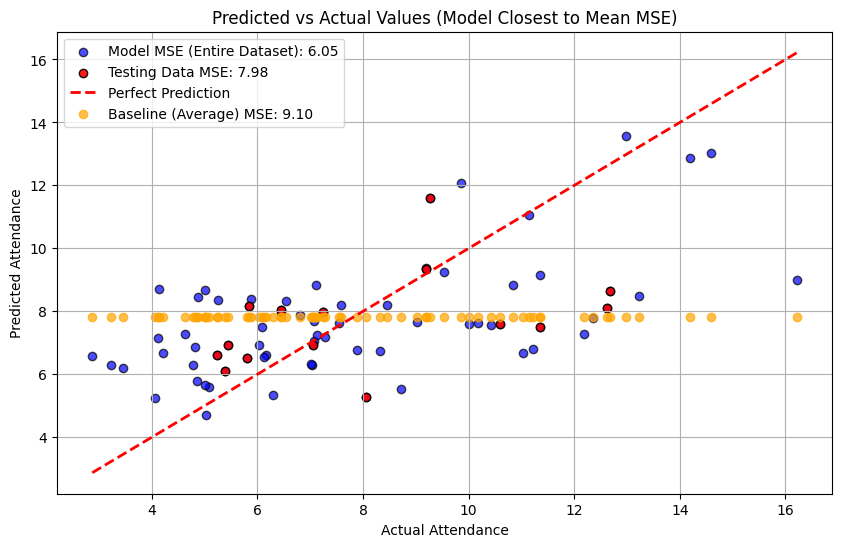

In [ ]:
# Assuming SFC is a DataFrame with the Attendance column
y = SFC["Attendance"]
X = SFC.drop(columns=["Attendance"])

# Initialize a list to store cross-validated MSEs and random states
cross_val_mse_list = []
random_state_list = []

# Define parameter grid for SGD
param_grid_sgd = {'alpha': np.linspace(0, 1, 30).tolist(), 'penalty': ['l2', 'l1', 'elasticnet']}

# Loop over 100 random states
for random_state in range(100):
    print(f"Processing random state {random_state}...")

    # Train-test split with the current random state
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Perform Grid Search for SGDRegressor with 5-fold cross-validation
    sgd = SGDRegressor(max_iter=1000, random_state=random_state)
    grid_search_sgd = GridSearchCV(sgd, param_grid_sgd, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_sgd.fit(X_train_scaled, y_train)

    # Get the best parameters
    best_params_sgd = grid_search_sgd.best_params_

    # Train SGD with the best alpha and penalty using cross-validation
    sgd_model = SGDRegressor(
        alpha=best_params_sgd['alpha'],
        penalty=best_params_sgd['penalty'],
        max_iter=1000,
        random_state=random_state
    )
    sgd_model.fit(X_train_scaled, y_train)

    # Perform cross-validation and get the mean cross-validation MSE
    cross_val_scores = cross_val_score(
        sgd_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error'
    )
    cross_val_mse = -np.mean(cross_val_scores)  # Mean of cross-validation MSEs
    cross_val_mse_list.append(cross_val_mse)
    random_state_list.append(random_state)

# Calculate the mean cross-validated MSE across all iterations
mean_cross_val_mse = np.mean(cross_val_mse_list)

# Find the closest MSE to the mean
closest_mean_index = np.argmin(np.abs(np.array(cross_val_mse_list) - mean_cross_val_mse))
closest_random_state = random_state_list[closest_mean_index]

# Train-test split with the selected random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=closest_random_state)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_scaled = scaler.transform(X)

# Train the SGDRegressor with the best parameters for the closest-to-mean model
sgd_model = SGDRegressor(
    alpha=param_grid_sgd['alpha'][0],  # Use the alpha from the grid search
    penalty=param_grid_sgd['penalty'][0],
    max_iter=1000,
    random_state=closest_random_state
)
sgd_model.fit(X_train_scaled, y_train)


y_pred = sgd_model.predict(X_scaled)
y_test_pred = sgd_model.predict(scaler.transform(X_test))

#average
average_attendance = np.mean(y)
y_avg_pred = np.full_like(y, average_attendance)


mse_model = mean_squared_error(y, y_pred)
mse_test = 7.98
mse_avg = mean_squared_error(y, y_avg_pred)

plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.7, edgecolor='k', label=f'Model MSE (Entire Dataset): {mse_model:.2f}', color='blue')
plt.scatter(y_test, y_test_pred, alpha=0.9, edgecolor='k', label=f'Testing Data MSE: {mse_test:.2f}', color='red')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.scatter(y, y_avg_pred, alpha=0.7, color='orange', label=f'Baseline (Average) MSE: {mse_avg:.2f}')
plt.title("Predicted vs Actual Values (Model Closest to Mean MSE)")
plt.xlabel("Actual Attendance")
plt.ylabel("Predicted Attendance")
plt.legend()
plt.grid(True)
plt.show()






In [ ]:

# Save the model and scaler for the closest-to-mean MSE model
closest_mean_index = np.argmin(np.abs(np.array(cross_val_mse_list) - mean_cross_val_mse))
closest_random_state = random_state_list[closest_mean_index]

# Train-test split using the closest-to-mean random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=closest_random_state)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SGDRegressor with the best parameters for the closest-to-mean MSE model
sgd_model = SGDRegressor(
    alpha=param_grid_sgd['alpha'][0],  # Use the alpha from the grid search
    penalty=param_grid_sgd['penalty'][0],  # Use the penalty from the grid search
    max_iter=1000,
    random_state=closest_random_state
)
sgd_model.fit(X_train_scaled, y_train)

# Save the model and scaler
joblib.dump(sgd_model, "closest_to_mean_model.pkl")
joblib.dump(scaler, "closest_to_mean_scaler.pkl")
print("Closest-to-mean model and scaler saved.")

# Define the new data
new_data = pd.DataFrame({
    "Matchday": [16],
    "Time": [16.5],
    "Ranking Home Team": [4],
    "Ranking Away Team": [2],
    "Precipitation (mm)": [0],
    "Temperature (°C)": [3.5],
    "Year": [2024],
    "Goals Scored in Last 5 Games": [7],
    "Goals Conceded in Last 5 Games": [8],
    "Number of Wins in Last 5 Games": [1],
    "Derby": [0],
    "Weekday_Saturday": [0],
    "Weekday_Weekday": [0]
})

# Load the saved model and scaler
loaded_model = joblib.load("closest_to_mean_model.pkl")
loaded_scaler = joblib.load("closest_to_mean_scaler.pkl")

# Standardize the new data
new_data_scaled = loaded_scaler.transform(new_data)

# Predict the attendance for the new data
predicted_attendance = loaded_model.predict(new_data_scaled)[0]

# Actual value
actual_attendance = 9.242

# Calculate the error
error = actual_attendance - predicted_attendance

# Print the results
print(f"Predicted Attendance: {predicted_attendance:.2f}")
print(f"Actual Attendance: {actual_attendance}")
print(f"Prediction Error: {error:.2f}")


Closest-to-mean model and scaler saved.
Predicted Attendance: 7.49
Actual Attendance: 9.242
Prediction Error: 1.76


In [ ]:


# Find the 25th percentile index
quantiles = np.percentile(cross_val_mse_list, [25, 50, 75])
quantile_25_index = np.argmin(np.abs(np.array(cross_val_mse_list) - quantiles[0]))
quantile_25_random_state = random_state_list[quantile_25_index]

# Train-test split using the 25th percentile random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=quantile_25_random_state)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SGDRegressor with the best parameters for the 25th percentile model
sgd_model = SGDRegressor(
    alpha=param_grid_sgd['alpha'][0],  # Use the alpha from the grid search
    penalty=param_grid_sgd['penalty'][0],  # Use the penalty from the grid search
    max_iter=1000,
    random_state=quantile_25_random_state
)
sgd_model.fit(X_train_scaled, y_train)

# Save the model and scaler
joblib.dump(sgd_model, "quantile_25_model.pkl")
joblib.dump(scaler, "quantile_25_scaler.pkl")
print("25th percentile model and scaler saved.")

# Define the new data
new_data = pd.DataFrame({
    "Matchday": [16],
    "Time": [16.5],
    "Ranking Home Team": [4],
    "Ranking Away Team": [2],
    "Precipitation (mm)": [0],
    "Temperature (°C)": [3.5],
    "Year": [2024],
    "Goals Scored in Last 5 Games": [7],
    "Goals Conceded in Last 5 Games": [8],
    "Number of Wins in Last 5 Games": [1],
    "Derby": [0],
    "Weekday_Saturday": [0],
    "Weekday_Weekday": [0]
})

# Load the saved model and scaler
loaded_model = joblib.load("quantile_25_model.pkl")
loaded_scaler = joblib.load("quantile_25_scaler.pkl")

# Standardize the new data
new_data_scaled = loaded_scaler.transform(new_data)

# Predict the attendance for the new data
predicted_attendance = loaded_model.predict(new_data_scaled)[0]

# Actual value
actual_attendance = 9.242

# Calculate the error
error = actual_attendance - predicted_attendance

# Print the results
print(f"Predicted Attendance: {predicted_attendance:.2f}")
print(f"Actual Attendance: {actual_attendance}")
print(f"Prediction Error: {error:.2f}")


25th percentile model and scaler saved.
Predicted Attendance: 7.87
Actual Attendance: 9.242
Prediction Error: 1.37


In [ ]:


# Find the 75th percentile index
quantiles = np.percentile(cross_val_mse_list, [25, 50, 75])
quantile_75_index = np.argmin(np.abs(np.array(cross_val_mse_list) - quantiles[2]))
quantile_75_random_state = random_state_list[quantile_75_index]

# Train-test split using the 75th percentile random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=quantile_75_random_state)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SGDRegressor with the best parameters for the 75th percentile model
sgd_model = SGDRegressor(
    alpha=param_grid_sgd['alpha'][0],  # Use the alpha from the grid search
    penalty=param_grid_sgd['penalty'][0],  # Use the penalty from the grid search
    max_iter=1000,
    random_state=quantile_75_random_state
)
sgd_model.fit(X_train_scaled, y_train)

# Save the model and scaler
joblib.dump(sgd_model, "quantile_75_model.pkl")
joblib.dump(scaler, "quantile_75_scaler.pkl")
print("75th percentile model and scaler saved.")

# Define the new data
new_data = pd.DataFrame({
    "Matchday": [16],
    "Time": [16.5],
    "Ranking Home Team": [4],
    "Ranking Away Team": [2],
    "Precipitation (mm)": [0],
    "Temperature (°C)": [3.5],
    "Year": [2024],
    "Goals Scored in Last 5 Games": [7],
    "Goals Conceded in Last 5 Games": [8],
    "Number of Wins in Last 5 Games": [1],
    "Derby": [0],
    "Weekday_Saturday": [0],
    "Weekday_Weekday": [0]
})

# Load the saved model and scaler
loaded_model = joblib.load("quantile_75_model.pkl")
loaded_scaler = joblib.load("quantile_75_scaler.pkl")

# Standardize the new data
new_data_scaled = loaded_scaler.transform(new_data)

# Predict the attendance for the new data
predicted_attendance = loaded_model.predict(new_data_scaled)[0]

# Actual value
actual_attendance = 9.242

# Calculate the error
error = actual_attendance - predicted_attendance

# Print the results
print(f"Predicted Attendance: {predicted_attendance:.2f}")
print(f"Actual Attendance: {actual_attendance}")
print(f"Prediction Error: {error:.2f}")


75th percentile model and scaler saved.
Predicted Attendance: 6.88
Actual Attendance: 9.242
Prediction Error: 2.36


In [ ]:


# Find the 50th percentile (median) index
quantiles = np.percentile(cross_val_mse_list, [25, 50, 75])
quantile_50_index = np.argmin(np.abs(np.array(cross_val_mse_list) - quantiles[1]))
quantile_50_random_state = random_state_list[quantile_50_index]

# Train-test split using the 50th percentile random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=quantile_50_random_state)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SGDRegressor with the best parameters for the 50th percentile (median) model
sgd_model = SGDRegressor(
    alpha=param_grid_sgd['alpha'][0],  # Use the alpha from the grid search
    penalty=param_grid_sgd['penalty'][0],  # Use the penalty from the grid search
    max_iter=1000,
    random_state=quantile_50_random_state
)
sgd_model.fit(X_train_scaled, y_train)

# Save the model and scaler
joblib.dump(sgd_model, "quantile_50_model.pkl")
joblib.dump(scaler, "quantile_50_scaler.pkl")
print("50th percentile (median) model and scaler saved.")

# Define the new data
new_data = pd.DataFrame({
    "Matchday": [16],
    "Time": [16.5],
    "Ranking Home Team": [4],
    "Ranking Away Team": [2],
    "Precipitation (mm)": [0],
    "Temperature (°C)": [3.5],
    "Year": [2024],
    "Goals Scored in Last 5 Games": [7],
    "Goals Conceded in Last 5 Games": [8],
    "Number of Wins in Last 5 Games": [1],
    "Derby": [0],
    "Weekday_Saturday": [0],
    "Weekday_Weekday": [0]
})

# Load the saved model and scaler
loaded_model = joblib.load("quantile_50_model.pkl")
loaded_scaler = joblib.load("quantile_50_scaler.pkl")

# Standardize the new data
new_data_scaled = loaded_scaler.transform(new_data)

# Predict the attendance for the new data
predicted_attendance = loaded_model.predict(new_data_scaled)[0]

# Actual value
actual_attendance = 9.242

# Calculate the error
error = actual_attendance - predicted_attendance

# Print the results
print(f"Predicted Attendance: {predicted_attendance:.2f}")
print(f"Actual Attendance: {actual_attendance}")
print(f"Prediction Error: {error:.2f}")


50th percentile (median) model and scaler saved.
Predicted Attendance: 7.79
Actual Attendance: 9.242
Prediction Error: 1.45


In [ ]:
actual_attendance = 9.242
Mean_Error = actual_attendance - average_y
print(Mean_Error)
average_y

1.4098493150684943


7.832150684931507

# Young Boys

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.model_selection import GridSearchCV, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score


data2 = pd.read_csv('/content/Cleaned_df_YB (1).csv')
data2= data2[data2['Competition'] == 'Super League']
data2 = data2[data2['Attendance'] <= 40000]
data2.reset_index(drop=True, inplace=True)
data2.head()

,Competition,Matchday,Time,Home Team,Ranking Home Team,Away Team,Ranking Away Team,Attendance,Precipitation (mm),Temperature (°C),...,Max Capacity,Home Team Goals Scored,Away Team Goals Scored,Match Type,Home Team Outcome,Away Team Outcome,Goals Scored in Last 5 Games,Goals Conceded in Last 5 Games,Number of Wins in Last 5 Games,Derby
0,Super League,4,19:30,BSC Young Boys,1,Grasshoppers,7,23663,0.0,17.4,...,31500,0,3,Normal Time,Loss,Win,8.0,6.0,2.0,0
1,Super League,3,19:30,BSC Young Boys,1,FC Aarau,10,15179,0.0,19.4,...,31500,0,0,Normal Time,Draw,Draw,7.0,8.0,2.0,0
2,Super League,6,16:15,BSC Young Boys,6,FC Zürich,1,13125,1.9,13.4,...,31500,3,1,Normal Time,Win,Loss,5.0,8.0,1.0,0
3,Super League,8,19:30,BSC Young Boys,4,FC Thun,5,22670,0.0,16.7,...,31500,0,0,Normal Time,Draw,Draw,6.0,7.0,2.0,1
4,Super League,10,16:00,BSC Young Boys,5,Neuchâtel Xamax,9,10165,0.0,18.1,...,31500,3,2,Normal Time,Win,Loss,4.0,11.0,1.0,0


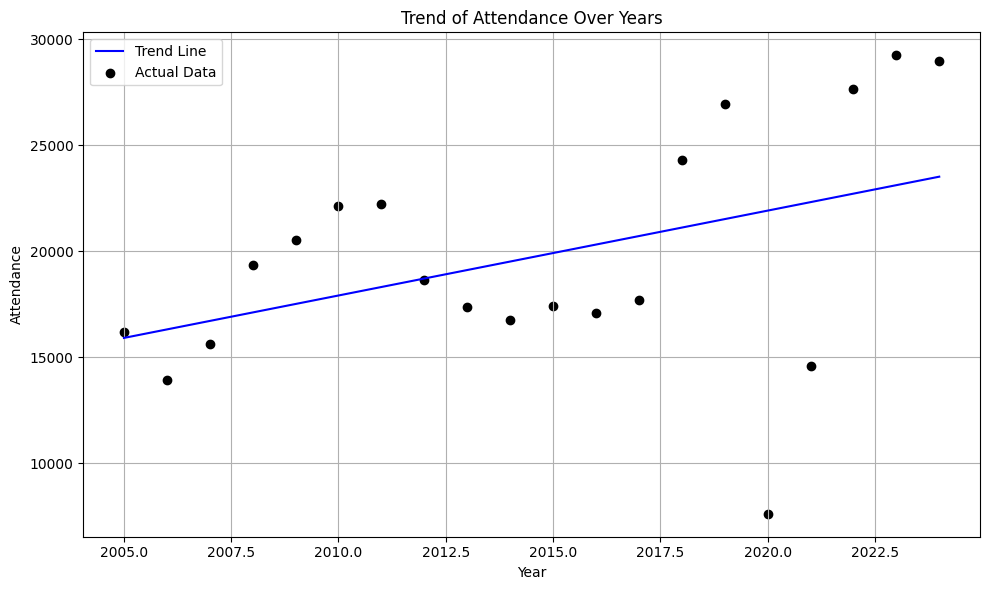

In [ ]:
data_yearly = data2.groupby('Year')['Attendance'].mean().reset_index()

trend_coefficients = np.polyfit(data_yearly['Year'], data_yearly['Attendance'], 1)
trend_line = np.poly1d(trend_coefficients)

plt.figure(figsize=(10, 6))
plt.plot(data_yearly['Year'], trend_line(data_yearly['Year']), color='blue', linestyle='-', label="Trend Line")
plt.scatter(data_yearly['Year'], data_yearly['Attendance'], color='black', label="Actual Data")
plt.title("Trend of Attendance Over Years")
plt.xlabel("Year")
plt.ylabel("Attendance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

columns_to_remove = [
    'Home Team', 'Away Team',
    'Home Team Goals Scored', 'Away Team Goals Scored',
    'Home Team Outcome', 'Away Team Outcome', 'Match Type', 'Max Capacity', 'Month'
]

yb = data2.drop(columns=columns_to_remove)
yb = yb.drop(columns=['Competition'])
weekday_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

yb['Weekday'] = yb['Weekday'].apply(
    lambda x: 'Weekday' if x in weekday_days else x
)
yb = pd.get_dummies(yb, columns=['Weekday'], drop_first=False)
yb = yb.replace({True: 1, False: 0})
def time_to_float(time_str):
    hours, minutes = map(int, time_str.split(":"))
    return hours + minutes / 60

yb["Time"] = yb["Time"].apply(time_to_float)
yb['Attendance'] = yb['Attendance'] / 1000

yb = yb.drop(columns=['Weekday_Sunday'])
yb

<ipython-input-49-5dd472ef81a9>:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  yb = yb.replace({True: 1, False: 0})


,Matchday,Time,Ranking Home Team,Ranking Away Team,Attendance,Precipitation (mm),Temperature (°C),Year,Goals Scored in Last 5 Games,Goals Conceded in Last 5 Games,Number of Wins in Last 5 Games,Derby,Weekday_Saturday,Weekday_Weekday
0,4,19.50,1,7,23.663,0.0,17.4,2005,8.0,6.0,2.0,0,1,0
1,3,19.50,1,10,15.179,0.0,19.4,2005,7.0,8.0,2.0,0,0,1
2,6,16.25,6,1,13.125,1.9,13.4,2005,5.0,8.0,1.0,0,0,0
3,8,19.50,4,5,22.670,0.0,16.7,2005,6.0,7.0,2.0,1,1,0
4,10,16.00,5,9,10.165,0.0,18.1,2005,4.0,11.0,1.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,6,20.50,12,10,28.079,0.0,23.1,2024,7.0,17.0,1.0,0,1,0
320,8,20.50,9,10,26.203,0.0,8.2,2024,4.0,13.0,0.0,0,1,0
321,10,18.00,12,1,31.500,0.0,11.0,2024,7.0,8.0,2.0,0,1,0
322,12,20.50,10,4,30.024,0.0,7.6,2024,10.0,2.0,4.0,1,0,1


In [ ]:
XY = pd.read_csv('/content/YB_Stage_1_Modelling_extensive_features.csv')
XY['Attendance'] = XY['Attendance'] / 1000
XY = XY.drop(columns = ['Weekday_Sunday'])

yb_std = XY["Attendance"].std()
yb_var = XY["Attendance"].var()

sfc_std = SFC["Attendance"].std()
sfc_var = SFC["Attendance"].var()

print(f"Young Boys Attendance - Std Dev: {yb_std}, Variance: {yb_var}")
print(f"Servette FC Attendance - Std Dev: {sfc_std}, Variance: {sfc_var}")

Young Boys Attendance - Std Dev: 5.87907929405931, Variance: 34.56357334583692
Servette FC Attendance - Std Dev: 3.0380999118200362, Variance: 9.230051074200912


In [ ]:
XY # this is the dataframe the has goals scored and conceded in last 5 HOME GAMES
#yb is the dataframe that has the haols scored and conceded in the last 5 home and away games

,Matchday,Time,Ranking Home Team,Ranking Away Team,Attendance,Precipitation (mm),Temperature (°C),Year,Goals Scored in Last 5 Games,Goals Conceded in Last 5 Games,Number of Wins in Last 5 Games,Derby,Weekday_Saturday,Weekday_Weekday
0,4,19.50,1,7,23.663,0.0,17.4,2005,8.0,6.0,2.0,0,1,0
1,3,19.50,1,10,15.179,0.0,19.4,2005,7.0,8.0,2.0,0,0,1
2,6,16.25,6,1,13.125,1.9,13.4,2005,5.0,8.0,1.0,0,0,0
3,8,19.50,4,5,22.670,0.0,16.7,2005,7.0,8.0,2.0,1,1,0
4,10,16.00,5,9,10.165,0.0,18.1,2005,5.0,7.0,1.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,6,20.50,12,10,28.079,0.0,23.1,2024,11.0,9.0,3.0,0,1,0
301,8,20.50,9,10,26.203,0.0,8.2,2024,7.0,10.0,1.0,0,1,0
302,10,18.00,12,1,31.500,0.0,11.0,2024,6.0,9.0,1.0,0,1,0
303,12,20.50,10,4,30.024,0.0,7.6,2024,3.0,7.0,1.0,1,0,1


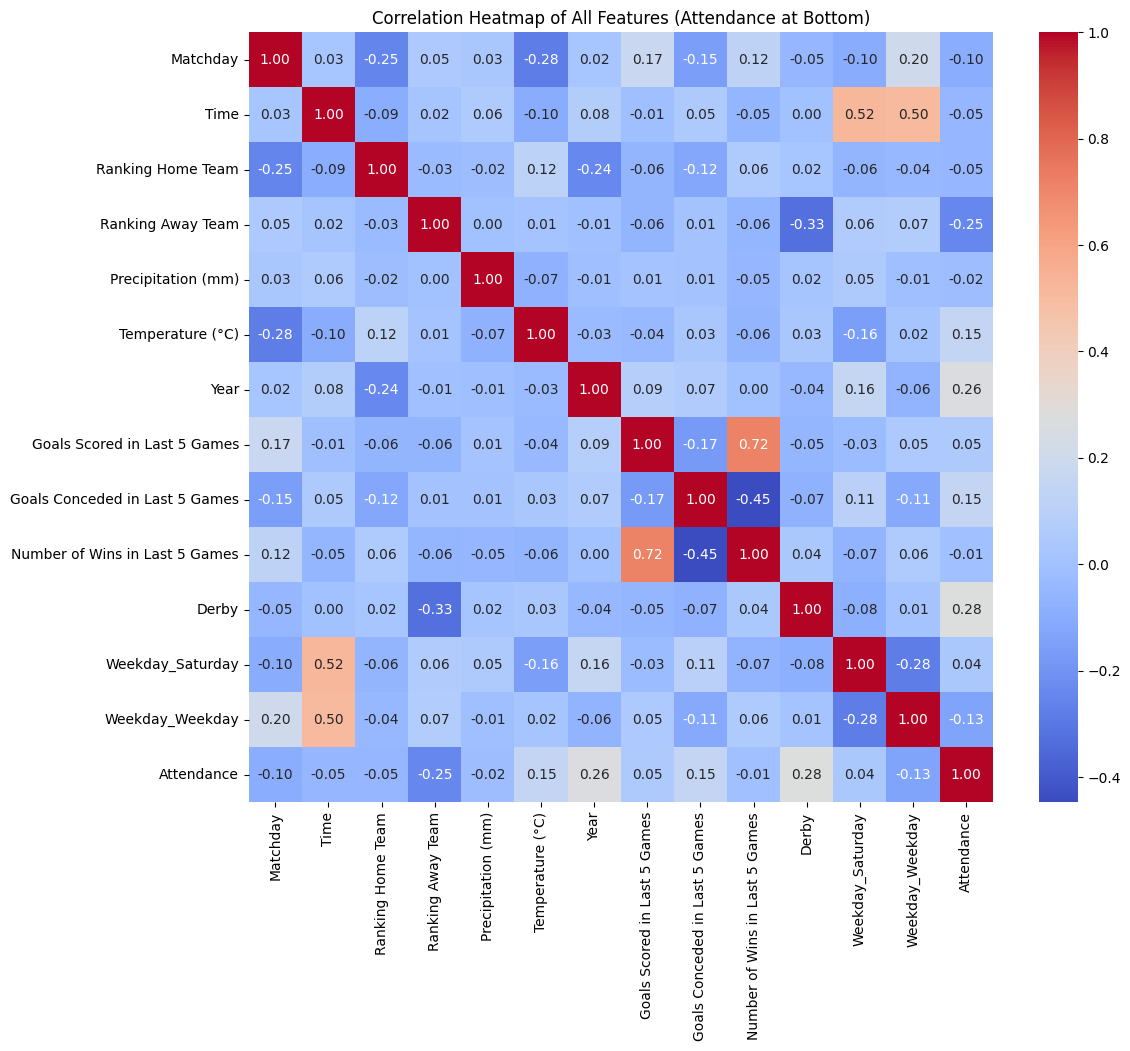

In [ ]:
correlation_matrix = yb.corr()

attendance_row = correlation_matrix.loc["Attendance"]
attendance_column = correlation_matrix["Attendance"]
correlation_matrix = correlation_matrix.drop(index="Attendance", columns="Attendance")
correlation_matrix.loc["Attendance"] = attendance_row
correlation_matrix["Attendance"] = attendance_column

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of All Features (Attendance at Bottom)')
plt.show()

Average Prediction: 20.38
MSE using average prediction: 34.45
MSE using moving average (window=5): 19.38
   Actual  Predicted_Moving_Avg  Predicted_Average
0  23.663              20.38483           20.38483
1  15.179              20.38483           20.38483
2  13.125              20.38483           20.38483
3  22.670              20.38483           20.38483
4  10.165              20.38483           20.38483
5   9.113              16.96040           20.38483
6  12.179              14.05040           20.38483
7  11.887              13.45040           20.38483
8  27.547              13.20280           20.38483
9   7.552              14.17820           20.38483


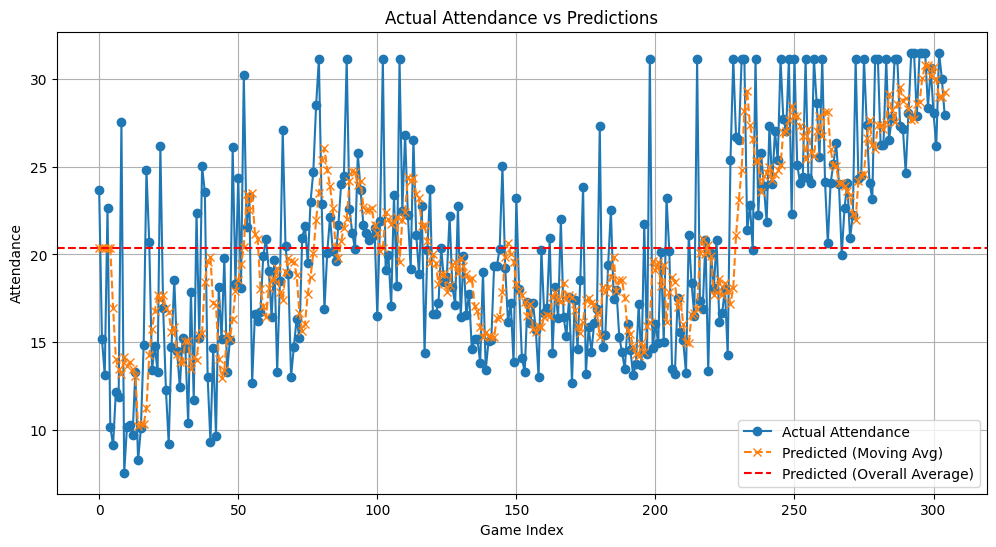

In [ ]:
attendance = XY["Attendance"]

# 1. Compare the average of all predictions to the actual values (MSE)
average_prediction = np.mean(attendance)
predictions = [average_prediction] * len(attendance)  # Same prediction for all games
mse_average = mean_squared_error(attendance, predictions)

print(f"Average Prediction: {average_prediction:.2f}")
print(f"MSE using average prediction: {mse_average:.2f}")

# 2. Moving average over previous 5 games to predict the next game's attendance
predicted_moving_avg = attendance.rolling(window=5).mean().shift(1)  # Rolling average with a shift for prediction
predicted_moving_avg = predicted_moving_avg.fillna(attendance.mean())  # Fill NaN for the first few games

# Calculate MSE for the moving average predictions
mse_moving_avg = mean_squared_error(attendance, predicted_moving_avg)

print(f"MSE using moving average (window=5): {mse_moving_avg:.2f}")

# 3. Display actual vs predictions for moving average
comparison_df = pd.DataFrame({
    "Actual": attendance,
    "Predicted_Moving_Avg": predicted_moving_avg,
    "Predicted_Average": predictions
})
print(comparison_df.head(10))

# 4. Plot actual vs moving average predictions
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(attendance.index, attendance, label="Actual Attendance", marker="o")
plt.plot(attendance.index, predicted_moving_avg, label="Predicted (Moving Avg)", linestyle="--", marker="x")
plt.axhline(average_prediction, color="red", linestyle="dashed", label="Predicted (Overall Average)")
plt.xlabel("Game Index")
plt.ylabel("Attendance")
plt.title("Actual Attendance vs Predictions")
plt.legend()
plt.grid(True)
plt.show()

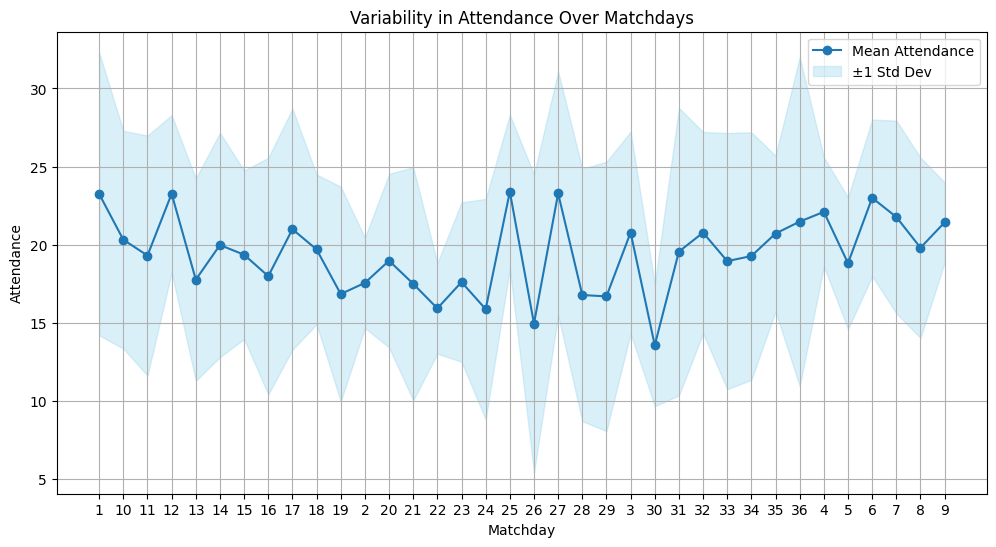

In [ ]:
# Group the data by 'Matchday' and calculate the mean and standard deviation of attendance
attendance_stats = yb.groupby("Matchday")["Attendance"].agg(["mean", "std"]).reset_index()

# Plot the variability in attendance over matchdays
plt.figure(figsize=(12, 6))
plt.plot(attendance_stats["Matchday"], attendance_stats["mean"], marker="o", label="Mean Attendance")
plt.fill_between(
    attendance_stats["Matchday"],
    attendance_stats["mean"] - attendance_stats["std"],
    attendance_stats["mean"] + attendance_stats["std"],
    color="skyblue",
    alpha=0.3,
    label="±1 Std Dev"
)

plt.title("Variability in Attendance Over Matchdays")
plt.xlabel("Matchday")
plt.ylabel("Attendance")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
yb.to_csv("yb.csv", index=False)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Assuming SFC is a DataFrame with the Attendance column
y = yb["Attendance"]
X = yb.drop(columns=["Attendance"])

# Initialize a dictionary to store the mean results for all random states
results = []

# Loop over 30 random states
for random_state in range(30):
    print(f"Processing random state {random_state}...")

    # Train-test split with the current random state
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Standardize features for linear models
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define parameter grids
    param_grid_ridge = {'alpha': np.linspace(74, 76, 10).tolist()}
    param_grid_lasso = {'alpha': np.linspace(0.45, 0.55, 10).tolist()}
    param_grid_elastic = {'alpha': np.linspace(0.51, 0.53, 10).tolist(), 'l1_ratio': np.linspace(0.5, 1.0, 10).tolist()}
    param_grid_sgd = {'alpha': np.linspace(0, 1, 30).tolist(), 'penalty': ['l2', 'l1', 'elasticnet']}
    param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None]}

    # Perform Grid Search for Ridge Regression
    ridge = Ridge()
    grid_search_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_ridge.fit(X_train_scaled, y_train)
    best_alpha_ridge = grid_search_ridge.best_params_['alpha']

    # Perform Grid Search for Lasso Regression
    lasso = Lasso()
    grid_search_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_lasso.fit(X_train_scaled, y_train)
    best_alpha_lasso = grid_search_lasso.best_params_['alpha']

    # Perform Grid Search for ElasticNet Regression
    elastic_net = ElasticNet()
    grid_search_elastic = GridSearchCV(elastic_net, param_grid_elastic, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_elastic.fit(X_train_scaled, y_train)
    best_params_elastic = grid_search_elastic.best_params_

    # Perform Grid Search for SGD Regressor
    sgd = SGDRegressor(max_iter=1000, random_state=random_state)
    grid_search_sgd = GridSearchCV(sgd, param_grid_sgd, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_sgd.fit(X_train_scaled, y_train)
    best_params_sgd = grid_search_sgd.best_params_

    # Perform Grid Search for Random Forest
    rf = RandomForestRegressor(random_state=random_state)
    grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search_rf.fit(X_train, y_train)
    best_params_rf = grid_search_rf.best_params_

    # Train models and evaluate
    def cross_validate_and_evaluate(model, X, y, model_name):
        y_pred = cross_val_predict(model, X, y, cv=5)
        mse = mean_squared_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        return mse, r2

    # Linear Regression
    lr_model = LinearRegression()
    lr_mse, lr_r2 = cross_validate_and_evaluate(lr_model, X_train_scaled, y_train, "Linear Regression")

    # Ridge Regression
    ridge_model = Ridge(alpha=best_alpha_ridge)
    ridge_mse, ridge_r2 = cross_validate_and_evaluate(ridge_model, X_train_scaled, y_train, "Ridge Regression")

    # Lasso Regression
    lasso_model = Lasso(alpha=best_alpha_lasso)
    lasso_mse, lasso_r2 = cross_validate_and_evaluate(lasso_model, X_train_scaled, y_train, "Lasso Regression")

    # ElasticNet Regression
    elastic_model = ElasticNet(alpha=best_params_elastic['alpha'], l1_ratio=best_params_elastic['l1_ratio'])
    elastic_mse, elastic_r2 = cross_validate_and_evaluate(elastic_model, X_train_scaled, y_train, "ElasticNet Regression")

    # Stochastic Gradient Descent
    sgd_model = SGDRegressor(alpha=best_params_sgd['alpha'], penalty=best_params_sgd['penalty'], max_iter=1000, random_state=random_state)
    sgd_mse, sgd_r2 = cross_validate_and_evaluate(sgd_model, X_train_scaled, y_train, "Stochastic Gradient Descent (SGD)")

    # Random Forest
    rf_model = RandomForestRegressor(**best_params_rf, random_state=random_state)
    rf_mse, rf_r2 = cross_validate_and_evaluate(rf_model, X_train, y_train, "Random Forest")

    # Append the results for this random state
    results.append({
        "random_state": random_state,
        "linear_mse": lr_mse,
        "ridge_mse": ridge_mse,
        "lasso_mse": lasso_mse,
        "elastic_mse": elastic_mse,
        "sgd_mse": sgd_mse,
        "rf_mse": rf_mse,
        "linear_r2": lr_r2,
        "ridge_r2": ridge_r2,
        "lasso_r2": lasso_r2,
        "elastic_r2": elastic_r2,
        "sgd_r2": sgd_r2,
        "rf_r2": rf_r2
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Print the mean MSE and R² across random states
print("Average Results Across Random States:")
print(results_df[["linear_mse", "ridge_mse", "lasso_mse", "elastic_mse", "sgd_mse", "rf_mse"]].mean())
print(results_df[["linear_r2", "ridge_r2", "lasso_r2", "elastic_r2", "sgd_r2", "rf_r2"]].mean())






Processing random state 0...
Processing random state 1...
Processing random state 2...
Processing random state 3...
Processing random state 4...
Processing random state 5...
Processing random state 6...
Processing random state 7...
Processing random state 8...
Processing random state 9...
Processing random state 10...
Processing random state 11...
Processing random state 12...
Processing random state 13...
Processing random state 14...
Processing random state 15...
Processing random state 16...
Processing random state 17...
Processing random state 18...
Processing random state 19...
Processing random state 20...
Processing random state 21...
Processing random state 22...
Processing random state 23...
Processing random state 24...
Processing random state 25...
Processing random state 26...
Processing random state 27...
Processing random state 28...
Processing random state 29...
Average Results Across Random States:
linear_mse     19.788203
ridge_mse      20.193792
lasso_mse      20.2068

Processing random state 0...
Processing random state 1...
Processing random state 2...
Processing random state 3...
Processing random state 4...
Processing random state 5...
Processing random state 6...
Processing random state 7...
Processing random state 8...
Processing random state 9...
Processing random state 10...
Processing random state 11...
Processing random state 12...
Processing random state 13...
Processing random state 14...
Processing random state 15...
Processing random state 16...
Processing random state 17...
Processing random state 18...
Processing random state 19...
Processing random state 20...
Processing random state 21...
Processing random state 22...
Processing random state 23...
Processing random state 24...
Processing random state 25...
Processing random state 26...
Processing random state 27...
Processing random state 28...
Processing random state 29...
Processing random state 30...
Processing random state 31...
Processing random state 32...
Processing random st

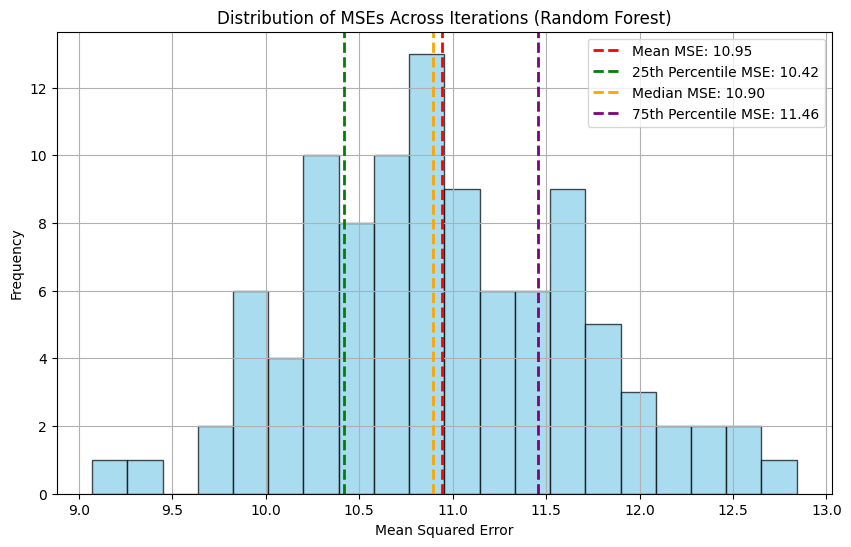

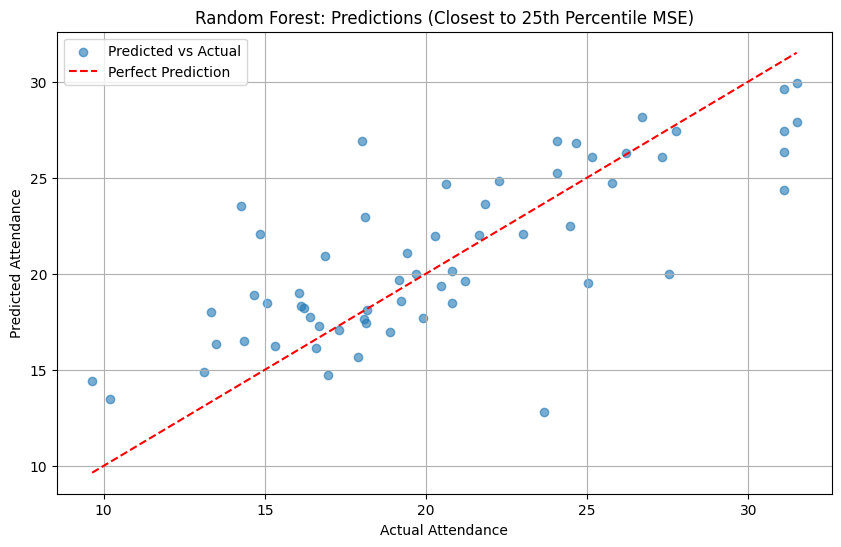

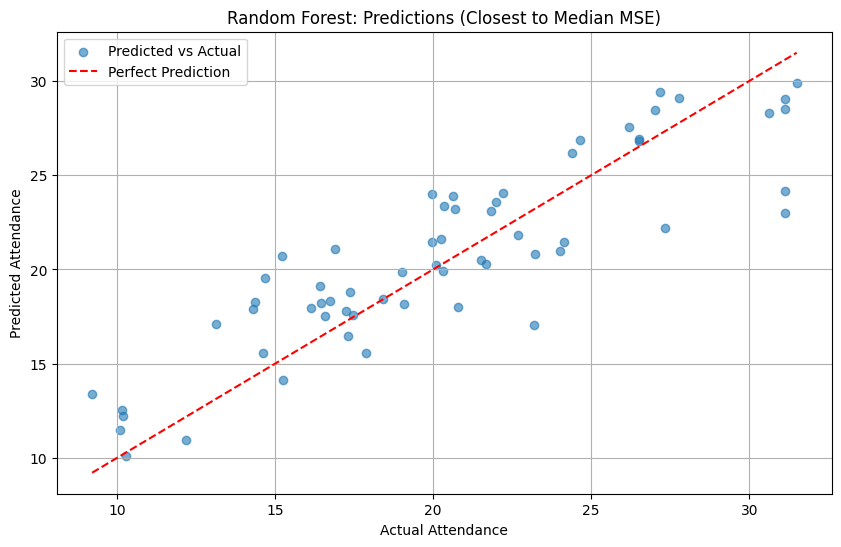

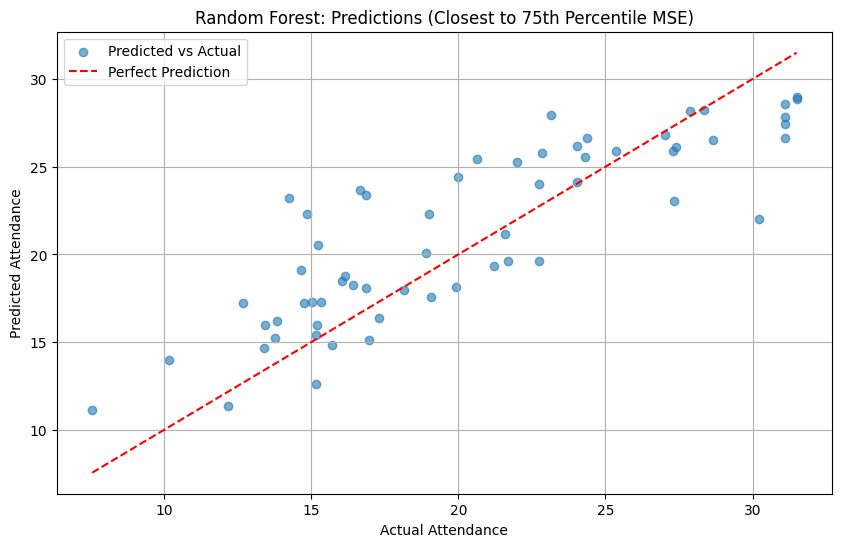

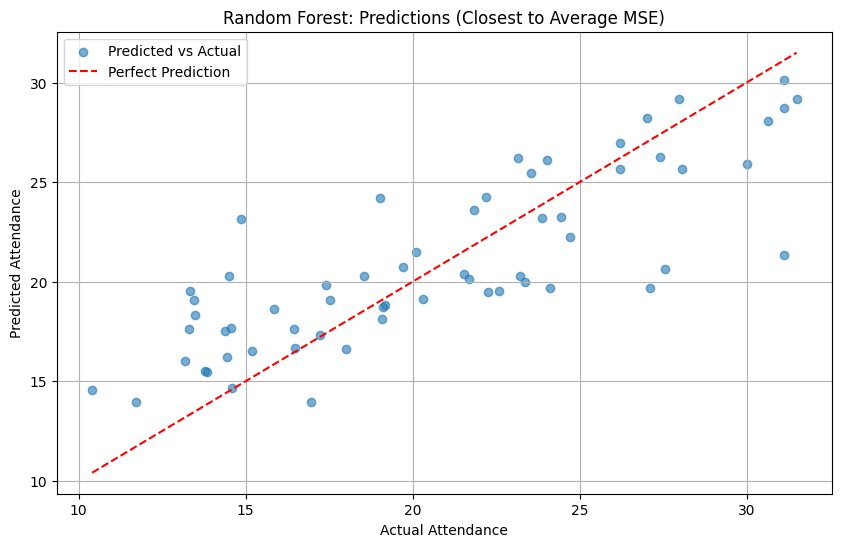

In [ ]:
y = XY["Attendance"]  # Scale down attendance
X = XY.drop(columns=["Attendance"])

# Initialize storage for MSEs and predictions
mse_list = []
predictions_list = []

# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Number of random states
random_states = 100

# Loop over random states
for random_state in range(random_states):
    print(f"Processing random state {random_state}...")

    # Train-test split with the current random state
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Perform Randomized Search for Random Forest
    rf = RandomForestRegressor(random_state=random_state)
    random_search_rf = RandomizedSearchCV(
        rf, param_distributions=param_grid_rf, n_iter=10, cv=5,
        scoring='neg_mean_squared_error', n_jobs=-1, random_state=random_state
    )
    random_search_rf.fit(X_train, y_train)

    # Get the best model
    best_rf = random_search_rf.best_estimator_

    # Perform cross-validation on the best model
    cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mean_cv_mse = -np.mean(cv_scores)  # Convert negative MSE back to positive MSE

    # Store the cross-validated MSE
    mse_list.append(mean_cv_mse)

    # Make predictions on the test set and store for plotting
    y_test_pred = best_rf.predict(X_test)
    predictions_list.append((y_test, y_test_pred))

# Calculate the average MSE
average_mse = np.mean(mse_list)
print(f"Average MSE across {random_states} iterations: {average_mse}")

# Plot the distribution of MSEs
percentiles = np.percentile(mse_list, [25, 50, 75])
plt.figure(figsize=(10, 6))
plt.hist(mse_list, bins=20, color="skyblue", edgecolor="black", alpha=0.7)
plt.axvline(average_mse, color='red', linestyle='dashed', linewidth=2, label=f"Mean MSE: {average_mse:.2f}")
plt.axvline(percentiles[0], color='green', linestyle='dashed', linewidth=2, label=f"25th Percentile MSE: {percentiles[0]:.2f}")
plt.axvline(percentiles[1], color='orange', linestyle='dashed', linewidth=2, label=f"Median MSE: {percentiles[1]:.2f}")
plt.axvline(percentiles[2], color='purple', linestyle='dashed', linewidth=2, label=f"75th Percentile MSE: {percentiles[2]:.2f}")
plt.title("Distribution of MSEs Across Iterations (Random Forest)")
plt.xlabel("Mean Squared Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# Identify models closest to 25th percentile, median, 75th percentile, and average MSE
closest_25th = np.argmin(np.abs(np.array(mse_list) - percentiles[0]))
closest_median = np.argmin(np.abs(np.array(mse_list) - percentiles[1]))
closest_75th = np.argmin(np.abs(np.array(mse_list) - percentiles[2]))
closest_average = np.argmin(np.abs(np.array(mse_list) - average_mse))

# Plot each model's predictions against actual values
def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, label="Predicted vs Actual")
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color="red", linestyle="--", label="Perfect Prediction")
    plt.xlabel("Actual Attendance")
    plt.ylabel("Predicted Attendance")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Closest to 25th Percentile
y_test_25th, y_pred_25th = predictions_list[closest_25th]
plot_predictions(y_test_25th, y_pred_25th, "Random Forest: Predictions (Closest to 25th Percentile MSE)")

# Closest to Median
y_test_median, y_pred_median = predictions_list[closest_median]
plot_predictions(y_test_median, y_pred_median, "Random Forest: Predictions (Closest to Median MSE)")

# Closest to 75th Percentile
y_test_75th, y_pred_75th = predictions_list[closest_75th]
plot_predictions(y_test_75th, y_pred_75th, "Random Forest: Predictions (Closest to 75th Percentile MSE)")

# Closest to Average
y_test_avg, y_pred_avg = predictions_list[closest_average]
plot_predictions(y_test_avg, y_pred_avg, "Random Forest: Predictions (Closest to Average MSE)")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
import joblib

# Assuming XY is already loaded with the correct dataset
y = XY["Attendance"] / 1000  # Scale down attendance
X = XY.drop(columns=["Attendance"])

# Initialize storage for MSEs and models
mse_list = []
predictions_list = []
models_list = []

# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Loop over random states
random_states = 100
for random_state in range(random_states):
    print(f"Processing random state {random_state}...")

    # Train-test split with the current random state
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Perform Randomized Search for Random Forest
    rf = RandomForestRegressor(random_state=random_state)
    random_search_rf = RandomizedSearchCV(
        rf, param_distributions=param_grid_rf, n_iter=10, cv=5,
        scoring='neg_mean_squared_error', n_jobs=-1, random_state=random_state
    )
    random_search_rf.fit(X_train, y_train)

    # Get the best model
    best_rf = random_search_rf.best_estimator_

    # Perform cross-validation on the best model
    cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mean_cv_mse = -np.mean(cv_scores)

    # Store the cross-validated MSE and model
    mse_list.append(mean_cv_mse)
    predictions_list.append((y_test, best_rf.predict(X_test)))
    models_list.append(best_rf)

# Calculate the average MSE
average_mse = np.mean(mse_list)
print(f"Average MSE across {random_states} iterations: {average_mse}")

# Find the model closest to the average MSE
closest_mean_index = np.argmin(np.abs(np.array(mse_list) - average_mse))
closest_mean_model = models_list[closest_mean_index]

# Save the closest-to-average model
joblib.dump(closest_mean_model, "closest_to_mean_model.pkl")
print("Model closest to average MSE saved.")

# Load the saved model for prediction
loaded_model = joblib.load("closest_to_mean_model.pkl")

# Define the new data
new_data = pd.DataFrame({
    "Matchday": [16],
    "Time": [16.5],
    "Ranking Home Team": [9],
    "Ranking Away Team": [7],
    "Precipitation (mm)": [0],
    "Temperature (°C)": [2],
    "Year": [2024],
    "Goals Scored in Last 5 Games": [10],
    "Goals Conceded in Last 5 Games": [6],
    "Number of Wins in Last 5 Games": [4],
    "Derby": [0],
    "Weekday_Saturday": [0],
    "Weekday_Weekday": [0]
})

# Predict the attendance for the new data
predicted_attendance = loaded_model.predict(new_data)[0]
actual_attendance = 29.124  # Actual attendance provided
prediction_error = actual_attendance - predicted_attendance

# Print the results
print(f"Predicted Attendance: {predicted_attendance:.2f}")
print(f"Actual Attendance: {actual_attendance}")
print(f"Prediction Error: {prediction_error:.2f}")


Processing random state 0...
Processing random state 1...
Processing random state 2...
Processing random state 3...
Processing random state 4...
Processing random state 5...
Processing random state 6...
Processing random state 7...
Processing random state 8...
Processing random state 9...
Processing random state 10...
Processing random state 11...
Processing random state 12...
Processing random state 13...
Processing random state 14...
Processing random state 15...
Processing random state 16...
Processing random state 17...
Processing random state 18...
Processing random state 19...
Processing random state 20...
Processing random state 21...
Processing random state 22...
Processing random state 23...
Processing random state 24...
Processing random state 25...
Processing random state 26...
Processing random state 27...
Processing random state 28...
Processing random state 29...
Processing random state 30...
Processing random state 31...
Processing random state 32...
Processing random st

Processing random state 0...
Processing random state 1...
Processing random state 2...
Processing random state 3...
Processing random state 4...
Processing random state 5...
Processing random state 6...
Processing random state 7...
Processing random state 8...
Processing random state 9...
Processing random state 10...
Processing random state 11...
Processing random state 12...
Processing random state 13...
Processing random state 14...
Processing random state 15...
Processing random state 16...
Processing random state 17...
Processing random state 18...
Processing random state 19...
Processing random state 20...
Processing random state 21...
Processing random state 22...
Processing random state 23...
Processing random state 24...
Processing random state 25...
Processing random state 26...
Processing random state 27...
Processing random state 28...
Processing random state 29...
Processing random state 30...
Processing random state 31...
Processing random state 32...
Processing random st

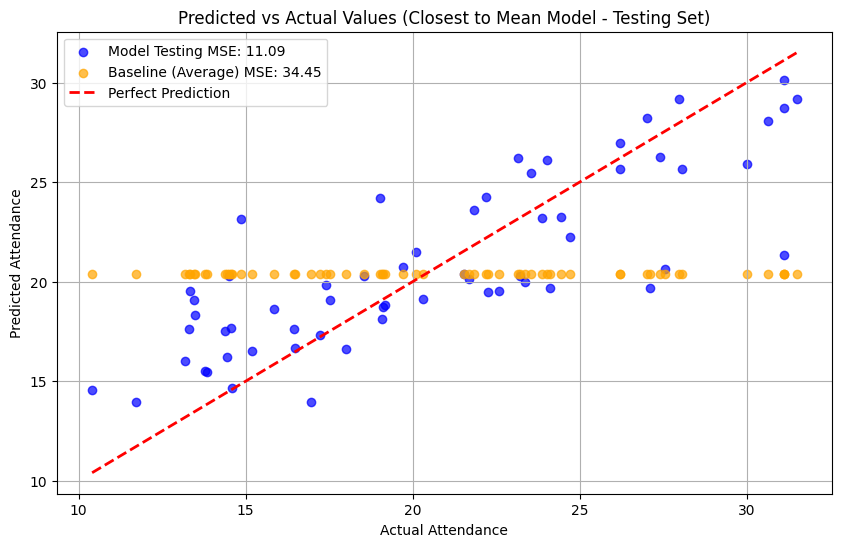

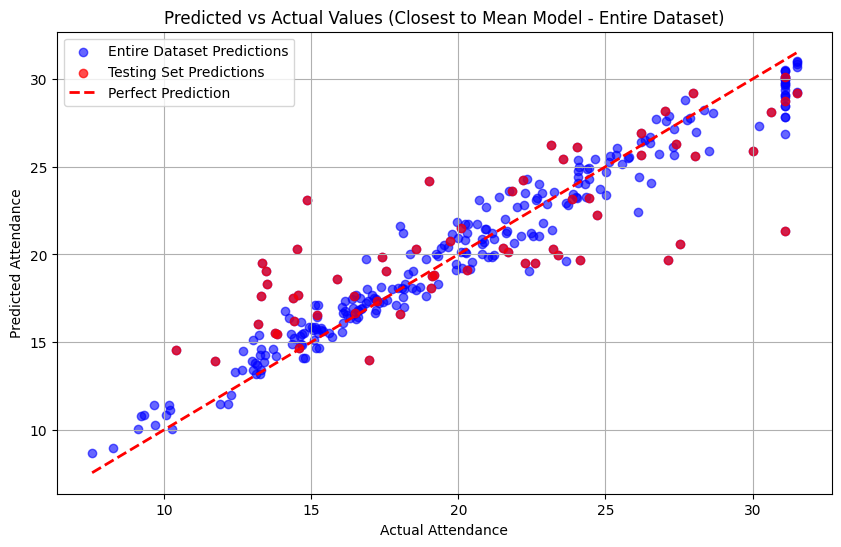

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error

# Assuming XY is already loaded with the correct dataset
y = XY["Attendance"] # Scale down attendance
X = XY.drop(columns=["Attendance"])

# Initialize storage for MSEs and predictions
mse_list = []
predictions_list = []
random_states = []

# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Number of random states
random_states_count = 100

# Loop over random states
for random_state in range(random_states_count):
    print(f"Processing random state {random_state}...")

    # Train-test split with the current random state
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

    # Perform Randomized Search for Random Forest
    rf = RandomForestRegressor(random_state=random_state)
    random_search_rf = RandomizedSearchCV(
        rf, param_distributions=param_grid_rf, n_iter=10, cv=5,
        scoring='neg_mean_squared_error', n_jobs=-1, random_state=random_state
    )
    random_search_rf.fit(X_train, y_train)

    # Get the best model
    best_rf = random_search_rf.best_estimator_

    # Perform cross-validation on the best model
    cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mean_cv_mse = -np.mean(cv_scores)  # Convert negative MSE back to positive MSE

    # Store the cross-validated MSE
    mse_list.append(mean_cv_mse)

    # Make predictions on the test set and store for plotting
    y_test_pred = best_rf.predict(X_test)
    predictions_list.append((y_test, y_test_pred))
    random_states.append(random_state)

# Calculate the average MSE
average_mse = np.mean(mse_list)
print(f"Average MSE across {random_states_count} iterations: {average_mse}")

# Find the closest-to-average model
closest_average_idx = np.argmin(np.abs(np.array(mse_list) - average_mse))
closest_random_state = random_states[closest_average_idx]
y_test, y_pred = predictions_list[closest_average_idx]

# Calculate the overall average attendance as a baseline
average_attendance = np.mean(y)
y_avg_pred = np.full_like(y, average_attendance)

# Calculate the MSE for the average predictor
mse_avg = mean_squared_error(y, y_avg_pred)

# Plot 1: Closest-to-mean model predictions vs actual values (testing set)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, label=f'Model Testing MSE: {mean_squared_error(y_test, y_pred):.2f}', color='blue')
plt.scatter(y_test, [average_attendance] * len(y_test), alpha=0.7, color='orange', label=f'Baseline (Average) MSE: {mse_avg:.2f}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Predicted vs Actual Values (Closest to Mean Model - Testing Set)")
plt.xlabel("Actual Attendance")
plt.ylabel("Predicted Attendance")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Closest-to-mean model predictions vs actual values (entire dataset)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=closest_random_state)
best_rf = RandomForestRegressor(random_state=closest_random_state)
best_rf.fit(X_train, y_train)
y_pred_entire = best_rf.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred_entire, alpha=0.6, label="Entire Dataset Predictions", color='blue')
plt.scatter(y_test, best_rf.predict(X_test), alpha=0.7, color='red', label="Testing Set Predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Predicted vs Actual Values (Closest to Mean Model - Entire Dataset)")
plt.xlabel("Actual Attendance")
plt.ylabel("Predicted Attendance")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
np.mean(XY["Attendance"])


20384.829508196723